In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Housekeeping only: keep version-deprecation notices out of our output.
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = [12, 5]

#Draw charts underneath the cell that made them, inside the notebook.
%matplotlib inline

# print() show text/values in output below cell.
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

Pandas version: 2.2.3
Numpy version: 1.26.4


In [36]:
raw = pd.read_csv("../../SGJobData.csv")
clean = pd.read_parquet("../../data/processed/jobs_clean.parquet")


In [40]:
raw.columns


Index(['categories', 'employmentTypes', 'metadata_expiryDate',
       'metadata_isPostedOnBehalf', 'metadata_jobPostId',
       'metadata_newPostingDate', 'metadata_originalPostingDate',
       'metadata_repostCount', 'metadata_totalNumberJobApplication',
       'metadata_totalNumberOfView', 'minimumYearsExperience',
       'numberOfVacancies', 'occupationId', 'positionLevels',
       'postedCompany_name', 'salary_maximum', 'salary_minimum', 'salary_type',
       'status_id', 'status_jobStatus', 'title', 'average_salary'],
      dtype='object')

In [38]:
clean.columns

Index(['employment_type', 'expiry_date', 'posted_on_behalf', 'job_id',
       'new_posting_date', 'original_posting_date', 'repost_count',
       'applications', 'views', 'min_years_experience', 'vacancies',
       'position_level', 'company', 'salary_max', 'salary_min', 'salary_type',
       'job_status', 'title', 'avg_salary', 'title_clean', 'seniority',
       'salary_band', 'experience_band', 'posting_month', 'posting_quarter',
       'days_live', 'applications_per_vacancy', 'apply_rate',
       'is_hard_to_fill', 'is_open', 'is_entry_friendly', 'job_key'],
      dtype='object')

In [41]:
#raw.head
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048585 entries, 0 to 1048584
Data columns (total 22 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   categories                          1044597 non-null  object 
 1   employmentTypes                     1044597 non-null  object 
 2   metadata_expiryDate                 1044597 non-null  object 
 3   metadata_isPostedOnBehalf           1048585 non-null  bool   
 4   metadata_jobPostId                  1044597 non-null  object 
 5   metadata_newPostingDate             1044597 non-null  object 
 6   metadata_originalPostingDate        1044597 non-null  object 
 7   metadata_repostCount                1048585 non-null  int64  
 8   metadata_totalNumberJobApplication  1048585 non-null  int64  
 9   metadata_totalNumberOfView          1048585 non-null  int64  
 10  minimumYearsExperience              1048585 non-null  int64  
 11  numberOfVac

In [66]:
#clean["posting_quarter"].value_counts()
#clean.info(verbose=True,show_counts=True)
x=clean.query('views==0')
x

,employment_type,expiry_date,posted_on_behalf,job_id,new_posting_date,original_posting_date,repost_count,applications,views,min_years_experience,...,experience_band,posting_month,posting_quarter,days_live,applications_per_vacancy,apply_rate,is_hard_to_fill,is_open,is_entry_friendly,job_key
27222,Permanent,2023-04-20,False,MCF-2023-0290299,2023-04-13,2023-04-13,0,0,0,1.0,...,1-2 yrs,2023-04-01,2023Q2,7,0.0,NaN,False,False,True,27222
194795,Contract,2023-07-07,False,MCF-2023-0499484,2023-06-30,2023-06-30,0,0,0,6.0,...,6-10 yrs,2023-06-01,2023Q2,7,0.0,NaN,False,True,False,194795
194816,Temporary,2023-07-30,False,MCF-2023-0499548,2023-06-30,2023-06-30,0,0,0,0.0,...,No experience,2023-06-01,2023Q2,30,0.0,NaN,False,True,True,194816
194831,Permanent,2023-07-30,False,MCF-2023-0499444,2023-06-30,2023-06-30,0,0,0,1.0,...,1-2 yrs,2023-06-01,2023Q2,30,0.0,NaN,False,True,True,194831
194878,Temporary,2023-07-07,False,MCF-2023-0499473,2023-06-30,2023-06-30,0,0,0,1.0,...,1-2 yrs,2023-06-01,2023Q2,7,0.0,NaN,False,True,True,194878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044551,Contract,2024-06-28,False,MCF-2024-0778216,2024-05-29,2024-05-29,0,0,0,2.0,...,1-2 yrs,2024-05-01,2024Q2,30,0.0,NaN,False,True,False,1044551
1044560,Full Time,2024-06-28,False,MCF-2024-0778251,2024-05-29,2024-05-29,0,0,0,3.0,...,3-5 yrs,2024-05-01,2024Q2,30,0.0,NaN,False,True,False,1044560
1044569,Full Time,2024-06-28,False,MCF-2024-0778280,2024-05-29,2024-05-29,0,0,0,1.0,...,1-2 yrs,2024-05-01,2024Q2,30,0.0,NaN,False,True,True,1044569
1044575,Full Time,2024-06-28,True,MCF-2024-0778234,2024-05-29,2024-05-29,0,0,0,1.0,...,1-2 yrs,2024-05-01,2024Q2,30,0.0,NaN,False,True,True,1044575


In [48]:
monthly = clean.pivot_table(
    index="new_posting_date", columns="applications", values="views", aggfunc="sum"
).resample("D").sum()

In [52]:
monthly

applications,0,1,2,3,4,5,6,7,8,9,...,785,846,914,921,922,1048,1052,1111,1199,1342
new_posting_date,,,,,,,,,,,,,,,,,,,,,
2023-02-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-02-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-02-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-02-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-02-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-25,2568.0,3136.0,10.0,0.0,97.0,0.0,88.0,95.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-05-26,5019.0,4583.0,122.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-05-27,9381.0,19921.0,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


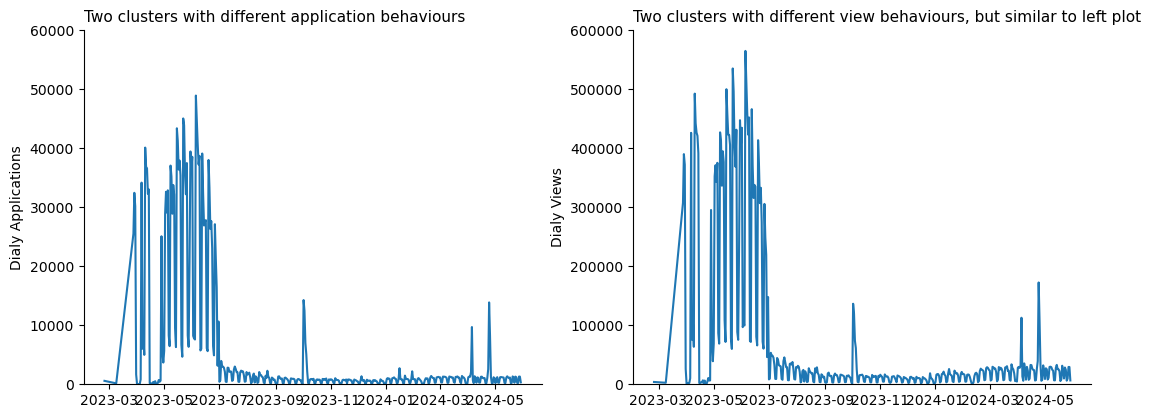

In [86]:
time_applications = clean.groupby('new_posting_date')['applications'].sum()
time_views = clean.groupby('new_posting_date')['views'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1]})

ax1.set_ylim(0, 60000)
ax1.set_ylabel("Dialy Applications")
ax1.set_title("Two clusters with different application behaviours", loc="left", fontsize=11)
ax1.spines[["top", "right"]].set_visible(False)
ax1.plot(time_applications)

ax2.set_ylim(0, 600000)
ax2.set_ylabel("Dialy Views")
ax2.set_title("Two clusters with different view behaviours, but similar to left plot", loc="left", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)
ax2.plot(time_views)

#ax1=time_applications.plot(kind='line', marker='o')
plt.show()

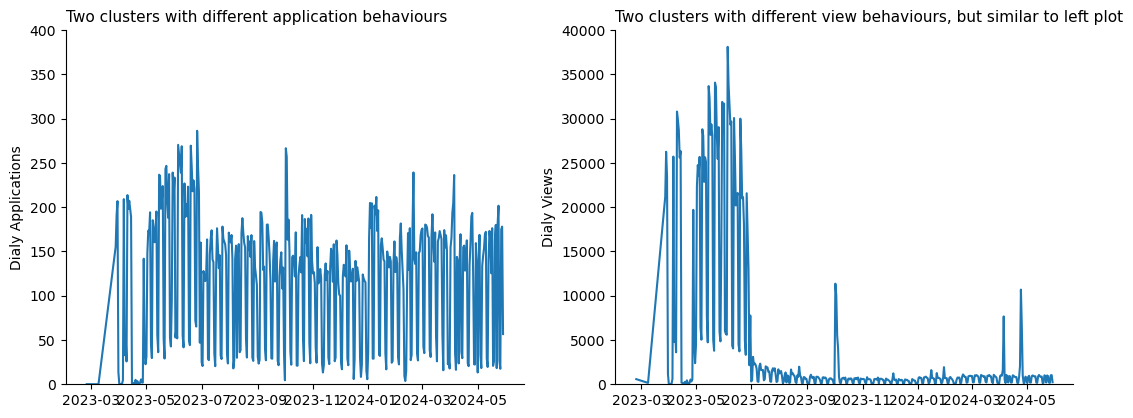

In [98]:
time_apply_rate = clean.groupby('new_posting_date')['apply_rate'].sum()
time_apply_vac = clean.groupby('new_posting_date')['applications_per_vacancy'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1]})

ax1.set_ylim(0, 400)
ax1.set_ylabel("Dialy Applications")
ax1.set_title("Two clusters with different application behaviours", loc="left", fontsize=11)
ax1.spines[["top", "right"]].set_visible(False)
ax1.plot(time_apply_rate)

ax2.set_ylim(0, 40000)
ax2.set_ylabel("Dialy Views")
ax2.set_title("Two clusters with different view behaviours, but similar to left plot", loc="left", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)
ax2.plot(time_apply_vac)

#ax1=time_applications.plot(kind='line', marker='o')
plt.show()